Test demo case

In [23]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.random import default_rng
from scipy.ndimage import zoom

from skimage.restoration import inpaint
from sklearn import metrics
from sklearn.utils.multiclass import unique_labels
from matplotlib.colors import ListedColormap
from scipy.ndimage import binary_dilation
from scipy.ndimage import distance_transform_edt
import matplotlib.patches as mpatches
from matplotlib.path import Path
from matplotlib import ticker
from matplotlib import rcParams

import sys
import os

# Add gridder and geo_vtk modules to path using relative paths
current_dir = os.getcwd()
sys.path.insert(0, os.path.join(current_dir, 'gridder'))
sys.path.insert(0, os.path.join(current_dir, 'geo_vtk', 'src'))

from gridder import Geo_Gridder
from vtkclass import VtkClass

# This notebook is prepared for upload to GitHub.
# All dependencies are imported above.
# Please ensure that any local paths (e.g., sys.path.insert) are updated or documented for portability.
# Data files required for execution (e.g., .npy, .gpkg, .txt) should be included or referenced in the repository's README.
# For reproducibility, consider adding requirements.txt or environment.yml with all necessary packages.

In [24]:

def distance(x, y, x0, y0):
    """
    Return distance between point
    P[x0,y0] and a curve (x,y)
    """
    d_x = x - x0
    d_y = y - y0
    dis = np.sqrt( d_x**2 + d_y**2 )
    return dis

def min_distance(x, y, x0, y0,precision=5):
    """
    Compute minimum/a distance/s between
    a point P[x0,y0] and a curve (x,y)
    rounded at `precision`.
    
    ARGS:
        x, y      (array)
        P         (tuple)
        precision (int)
        
    Returns min indexes and distances array.
    """
    # compute distance
    d = distance(x, y,x0, y0)
    d = np.round(d, precision)
    # find the minima
    glob_min_idxs = np.argwhere(d==np.min(d)).ravel()
    return glob_min_idxs, d





def onclick(event):
   print([event.xdata, event.ydata])

def arclength(x, y, a, b):
    """
    Computes the arclength of the given curve
    defined by (x0, y0), (x1, y1) ... (xn, yn)
    over the provided bounds, `a` and `b`.

    Parameters
    ----------
    x: numpy.ndarray
        The array of x values

    y: numpy.ndarray
        The array of y values corresponding to each value of x

    a: int
        The lower limit to integrate from

    b: int
        The upper limit to integrate to

    Returns
    -------
    numpy.float64
        The arclength of the curve

    """
    bounds = (x >= a) & (x <= b)
    # print(bounds)
    return np.trapz((
        np.sqrt(
            1 + np.gradient(y[bounds], x[bounds])
        ) ** 2),
        x[bounds]
    )

In [25]:
map=np.array([[200,200,200], #anthropogenic
		[157,78,64], #peat
		[0,146,0], #clay
		[194,207,92], #silty clay
		[255,255,255], # nothing
		[255,255,0], # fine
		[243,225,6], # medium
		[231,195,22], #coarse
		[216,163,32], #gravel
		[95,95,255]]) # shells
map=map/255
my_map=ListedColormap(map,name='IMOD')

# Define labels globally so they are accessible from all functions
labels = np.array([
	'anthropogenic',
	'peat',
	'clay',
	'silty clay',
	'nothing',
	'fine sand',
	'medium sand',
	'coarse sand',
	'gravel',
	'shells'
])

In [26]:
def plot_model_with_validation_real(real, basis, del1, X, Y, tt, del_perc=None, cmap='viridis', random_indices=None,filename='model_with_validation.pdf'):

    # Prepare polygon mask for topography
    polygon = tt.T
    points = np.c_[X.ravel(), Y.ravel()]
    poly_path = Path(polygon)
    inside = poly_path.contains_points(points)
    inside_mask = inside.reshape(X.shape)
    del1_plot = del1.copy()
    del1_plot[~inside_mask] = np.nan
    if del_perc is not None:
        del_perc = del_perc.copy()
        del_perc[~inside_mask] = np.nan

    unique_values = np.unique(basis.ravel()[~np.isnan(basis.ravel())])

    # Validation/confusion matrix
    if random_indices is None:
        random_indices = np.arange(real.shape[1])
    test_data = real[:, random_indices].ravel()
    test_data_plot = np.nan * np.ones_like(real)
    pred_data_plot = np.nan * np.ones_like(real)
    test_data_plot[:, random_indices] = real[:, random_indices]
    pred_data_plot[:, random_indices] = del1_plot[:, random_indices]
    pred_data = del1[:, random_indices].ravel()
    i_keep = np.where(np.isfinite(test_data))[0]

    # Set global style
    plt.rcParams.update({'font.size': 14, 'axes.titlesize': 18, 'axes.labelsize': 16})

    fig, axes = plt.subplots(4, 1, figsize=(18, 24), constrained_layout=True)

    # Calculate common x-limits (min/max) for all subplots
    x_min = np.nanmin(X)
    x_max = np.nanmax(X)

    # Plot 1: All boreholes and validation
    im1 = axes[0].pcolor(X + 25, Y - 0.125, np.round(real), cmap=cmap, vmin=0, vmax=9, edgecolors='w', linewidths=1.0, shading='auto')
    axes[0].pcolor(X + 25, Y - 0.125, np.round(test_data_plot), cmap=cmap, vmin=0, vmax=9, edgecolors='k', linewidths=1.0, shading='auto')
    axes[0].set_ylabel('Elevation (m)')
    axes[0].set_title('Boreholes used for inpainting - Boreholes used for validation')
    axes[0].set_aspect('auto')
    axes[0].set_xlim(x_min, x_max)
    axes[0].grid(True, linestyle='--', alpha=0.5)
    cmap_obj = im1.get_cmap()
    norm = im1.norm
    legend_handles = []
    for idx, value in enumerate(unique_values):
        color = cmap_obj(norm(value))
        label = labels[int(value)] if int(value) < len(labels) else f'Unit {value}'
        patch = mpatches.Patch(color=color, label=label)
        legend_handles.append(patch)
    axes[0].legend(handles=legend_handles, title="Legend", loc='upper left', bbox_to_anchor=(1.01, 1), ncol=1, frameon=True)

    # Plot 2: Validation vs Prediction
    axes[1].pcolor(X + 50, Y - 0.125, np.round(test_data_plot), cmap=cmap, vmin=0, vmax=9, edgecolors='k', linewidths=1.0, shading='auto')
    axes[1].pcolor(X + 25, Y - 0.125, np.round(pred_data_plot), cmap=cmap, vmin=0, vmax=9, edgecolors='r', linewidths=1.0, shading='auto')
    axes[1].set_ylabel('Elevation (m)')
    axes[1].set_title('Validation boreholes - Predicted boreholes')
    axes[1].set_aspect('auto')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    # Add legend for validation and prediction
    red_patch = mpatches.Patch(edgecolor='r', facecolor='none', linewidth=2, label='Prediction')
    black_patch = mpatches.Patch(edgecolor='k', facecolor='none', linewidth=2, label='Validation')
    axes[1].legend(handles=[red_patch, black_patch], loc='upper left', bbox_to_anchor=(1.01, 1), frameon=True)

    # Plot 3: Reconstructed model
    axes[2].pcolor(X, Y, np.round(del1_plot), cmap=cmap, vmin=0, vmax=9, edgecolors='w', linewidths=0.5, shading='auto')
    axes[2].set_title('Reconstructed model')
    axes[2].pcolor(X + 25, Y - 0.125, np.round(real), cmap=cmap, vmin=0, vmax=9, edgecolors='b', linewidths=0.5, shading='auto')
    axes[2].pcolor(X + 25, Y - 0.125, np.round(pred_data_plot), cmap=cmap, vmin=0, vmax=9, edgecolors='r', linewidths=1.0, shading='auto')

    axes[2].set_ylabel('Elevation (m)')
    axes[2].set_aspect('auto')
    axes[2].grid(True, linestyle='--', alpha=0.5)
    # Add legend for validation and prediction
    red_patch = mpatches.Patch(edgecolor='b', facecolor='none', linewidth=2, label='Data Used')
    black_patch = mpatches.Patch(edgecolor='r', facecolor='none', linewidth=2, label='Prediction')
    axes[2].legend(handles=[red_patch, black_patch], loc='upper left', bbox_to_anchor=(1.01, 1), frameon=True)


    # Plot 4: Uncertainty
    im2 = axes[3].pcolor(X, Y, del_perc, cmap='gist_gray', vmin=0, vmax=100, shading='auto')
    axes[3].set_title('% Uncertainty')
    axes[3].set_ylabel('Elevation (m)')
    axes[3].set_xlabel('Distance (m)')
    axes[3].set_aspect('auto')
    axes[3].grid(True, linestyle='--', alpha=0.5)
    cbar = fig.colorbar(im2, ax=axes[3], orientation='vertical', pad=0.02, fraction=0.04)
    cbar.set_label('% Error')
    cbar.ax.tick_params(labelsize=12)
    rcParams['pdf.fonttype'] = 42  # Ensures fonts are embedded as TrueType
    fig.savefig(filename, format="pdf", bbox_inches="tight")
    # Confusion Matrix (only classes present in true or predicted labels)
    present_true = np.unique(test_data[i_keep])
    present_pred = np.unique(pred_data[i_keep])
    present_classes = np.unique(np.concatenate([present_true, present_pred]))
    # Remove nan and zero if not present
    present_classes = present_classes[np.isfinite(present_classes)]
    # Only keep classes with at least one true or predicted sample
    mask_present = np.isin(test_data[i_keep], present_classes) | np.isin(pred_data[i_keep], present_classes)
    # Get corresponding labels
    present_labels = [labels[int(c)] if int(c) < len(labels) else f'Unit {c}' for c in present_classes]
    fig_cm, ax_cm = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)
    confusion_matrix = metrics.confusion_matrix(
        test_data[i_keep][mask_present], 
        pred_data[i_keep][mask_present], 
        labels=present_classes
    )
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix)
    cm_display.plot(ax=ax_cm, cmap=plt.cm.Blues, xticks_rotation=45, colorbar=False)
    ax_cm.set_title('Confusion Matrix (Present Classes)', fontsize=18)
    ax_cm.set_xticks(np.arange(len(present_labels)))
    ax_cm.set_yticks(np.arange(len(present_labels)))
    ax_cm.set_xticklabels(present_labels, rotation=45, ha='right', fontsize=14)
    ax_cm.set_yticklabels(present_labels, fontsize=14)
    ax_cm.grid(False)
    fig_cm.savefig(filename[:-4]+'_validation.pdf', format="pdf", bbox_inches="tight")
    plt.show()


In [6]:
def plot_model_with_validation(real, basis, del1, del_perc=None, cmap='viridis', random_indices=None):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
    del1 = del1.copy()
    del1[np.isnan(real)] = np.nan

    # First subplot
    im1 = axes[0][0].imshow(basis, cmap=cmap, vmin=0, vmax=9)
    axes[0][0].set_ylabel('Depth (cm)')
    axes[0][0].set_title('All boreholes')
    axes[0][0].set_xlim(-0.5-2, basis.shape[1] - 0.5 + 2)

    # Second subplot
    if del_perc is None:
        uncertainty = 1 - np.abs(del1 - 0.5) * 2
        uncertainty_percent = uncertainty * 100
    else:
        uncertainty_percent = del_perc

    im2 = axes[0][1].imshow(uncertainty_percent, cmap='gist_gray', vmin=0, vmax=100)
    axes[0][1].set_title('% Uncertainty')
    axes[0][1].set_xlabel('Distance (m)')
    axes[0][1].set_xlim(-0.5-2, basis.shape[1] - 0.5 + 2)
    cbar = fig.colorbar(im2, ax=axes[0][1], orientation='vertical', pad=0.02, fraction=0.046)
    cbar.set_label('% Error')

    # Third subplot
    axes[0][2].imshow(np.round(del1), cmap=cmap, vmin=0, vmax=9)
    axes[0][2].set_title('Reconstructed model')
    unique_values = np.unique(basis.ravel()[~np.isnan(basis.ravel())])

    cmap_obj = im1.get_cmap()
    norm = im1.norm
    legend_handles = []
    for idx, value in enumerate(unique_values):
        color = cmap_obj(norm(value))
        if int(value) < len(labels):
            label = labels[int(value)]
        else:
            label = f'Unit {value}'
        patch = mpatches.Patch(color=color, label=label)
        legend_handles.append(patch)

    axes[0][0].legend(handles=legend_handles, title="Legend",
                      loc='upper left', bbox_to_anchor=(1.05, 1), ncol=1, frameon=True)

    # Fourth subplot
    axes[1][0].imshow(np.round(real), cmap=cmap, vmin=0, vmax=9)
    axes[1][0].set_title('Real model')

    # Validation/confusion matrix
    if random_indices is None:
        random_indices = np.arange(real.shape[1])
    test_data = real[:, random_indices].ravel()
    pred_data = del1[:, random_indices].ravel()
    i_keep = np.where(np.isfinite(test_data))[0]
    confusion_matrix = metrics.confusion_matrix(test_data[i_keep], pred_data[i_keep])
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix)
    cm_display.plot(ax=axes[1][1], cmap=plt.cm.Blues, xticks_rotation=45, colorbar=False)
    axes[1][1].set_title('Confusion Matrix')

    tick_labels = [h.get_label() for h in legend_handles]
    axes[1][1].set_xticks(np.arange(len(tick_labels)))
    axes[1][1].set_yticks(np.arange(len(tick_labels)))
    axes[1][1].set_xticklabels(tick_labels, rotation=45, ha='right')
    axes[1][1].set_yticklabels(tick_labels)

    # Hide unused subplot
    axes[1][2].axis('off')
    diff_binary = (np.round(real) != np.round(del1)).astype(int)
    axes[1][2].imshow(diff_binary, cmap='gray', vmin=0, vmax=1)
    axes[1][2].set_title('Binary Difference Mask')

    #plt.tight_layout()
    plt.show()


In [7]:
def plot_confusion_matrix(y_true, y_pred, labels=None, title='Confusion Matrix', cmap=plt.cm.Blues):
    """
    Plots a confusion matrix.
    
    Parameters:
    - y_true: true labels
    - y_pred: predicted labels
    - labels: list of class names
    - title: title of the plot
    - cmap: colormap for the matrix
    """
    fig_cm, ax_cm = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)
    confusion_matrix = metrics.confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix)
    cm_display.plot(ax=ax_cm, cmap=plt.cm.Blues, xticks_rotation=45, colorbar=False)
    ax_cm.set_title('Confusion Matrix', fontsize=18)
    ax_cm.set_xticks(np.arange(len(labels)))
    ax_cm.set_yticks(np.arange(len(labels)))
    ax_cm.set_xticklabels(labels, rotation=45, ha='right', fontsize=14)
    ax_cm.set_yticklabels(labels, fontsize=14)
    ax_cm.grid(False)
    plt.show()
    rcParams['pdf.fonttype'] = 42  # Ensures fonts are embedded as TrueType
    fig_cm.savefig("confusion_matrix.pdf", format="pdf", bbox_inches="tight")

We read data from https://docs.gempy.org/tutorials/z_other_tutorials/video_tutorial_model_1.html#sphx-glr-tutorials-z-other-tutorials-video-tutorial-model-1-py.


The full model recostructed with gempy is names as gempy_full.
From that model we will keep only where we get inortaion form the tutorial, and name it as gempy_test.
The points is the file donloaded from the same tutorial, and we used ot to contruct the gempy_test and to viusalize the resutls 


In [8]:
import pandas as pd
gempy_full=np.flipud(np.load('lith_3d_2d.npy'))
gempy_test=np.flipud(np.load('lith_3d_2d_with_points.npy'))

# since we are using the colorscale of geotop, there is no class 4. Thus we convert class 4 from gemppy, to 5, only for visualization reasonts
gempy_full[gempy_full==4] = 5
gempy_test[gempy_test==4] = 5

points=pd.read_csv('surface_points_with_indices.csv')

nx = gempy_test.shape[1]
ny = gempy_test.shape[0]


[1. 2. 3. 5.]


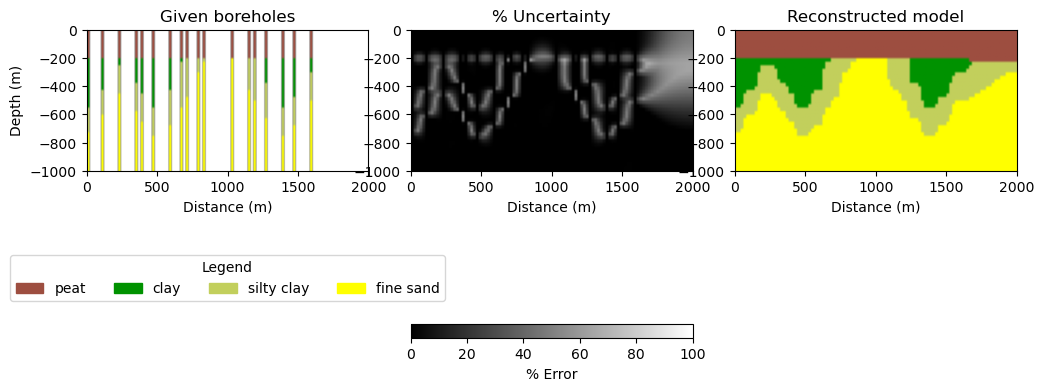

[1 2 3 5]


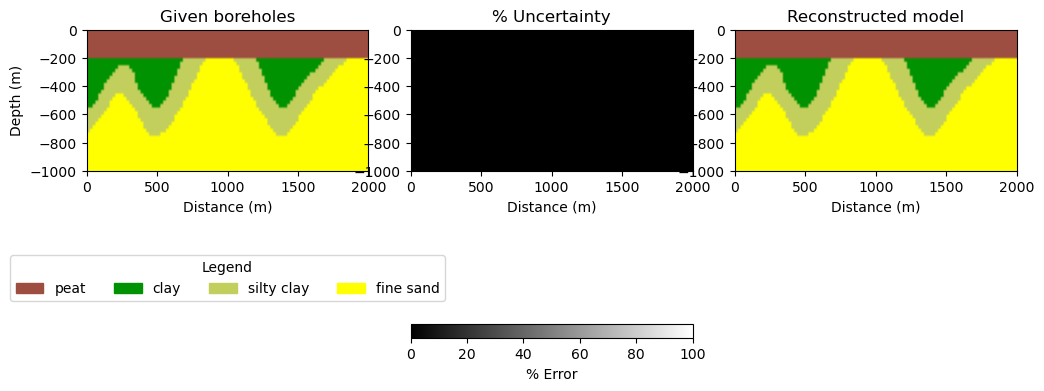

In [22]:
int1 = Geo_Gridder(None, None)
int1.one_vs_all(image=gempy_test, x_weight=1.0, y_weight=1)



int1.plot_model(cmap=my_map,filename='model_gempy.pdf',labels=labels,extent=[0, 2000, -1000, 0])



int1.one_vs_all(image=gempy_full, x_weight=1.0, y_weight=1.0)
int1.plot_model(cmap=my_map,filename='model_full.pdf',labels=labels,extent=[0, 2000, -1000, 0])
